In [1]:
import numpy as np
import pandas as pd
import os, sys
from pyLIMA import event
from scipy.signal import find_peaks
from tqdm.auto import tqdm
from pyLIMA import telescopes
from pyLIMA.models import USBL_model
from astropy.time import Time
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.table import QTable
from astropy.time import Time
from astropy.coordinates import SkyCoord


import copy
from pathlib import Path
# script_dir = Path(__file__).parent
import sys
script_dir='/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/'
sys.path.append('/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/'+'/photutils/')
# import sys
# sys.path.append("roman_rubin/photutils/")
# sys.path.append("simulation_Rubin/dp0_rubin/")
# from bandpass import Bandpass

from pyLIMA import event
from pyLIMA import telescopes
from pyLIMA.toolbox import time_series
from pyLIMA.simulations import simulator
from pyLIMA.models import PSBL_model
from pyLIMA.models import USBL_model
from pyLIMA.models import FSPLarge_model
from pyLIMA.models import PSPL_model
from pyLIMA.fits import TRF_fit
from pyLIMA.fits import DE_fit
from pyLIMA.fits import MCMC_fit
from pyLIMA.outputs import pyLIMA_plots
from pyLIMA.outputs import file_outputs

/home/anibal-pc/anaconda3/envs/pyLIMA_updated/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# current_path = os.path.dirname(os.getcwd())
# # print(current_path)
# i=18#18 #select one event by its index in the TRILEGAL set
# model='USBL'

# path_TRILEGAL_set= current_path+'/TRILEGAL/PB_planet_split_1.csv'
# path_to_save_model= current_path+'/test_sim_fit/'
# path_to_save_fit= current_path+'/test_sim_fit/'
# path_ephemerides= current_path+'/ephemerides/Roman_positions.npy'
# # '/home/anibal-pc/roman_rubin_sim/'#
# # '/home/anibal-pc/roman_rubin_sim/Roman_positions.npy'
# path_dataslice = current_path+'/opsims/baseline/dataSlice.npy'
# path_fit_rr = path_to_save_fit+f'/Event_RR_{i}_TRF.npy'
# path_fit_roman =  path_to_save_fit+f'/Event_Roman_{i}_TRF.npy'
# colorbands={'W149':'b', 'u':'purple', 'g':'g', 'r':'red',
#           'i':'yellow', 'z':'k', 'y':'cyan'}

In [11]:
# pd_planets = pd.read_csv(path_TRILEGAL_set)
# event_params = pd_planets.iloc[int(i)]
# event_params

In [5]:

# rubin_ts = ts_rubin(path_dataslice)
# rubin_ts

In [24]:

# Roman_tot = roman_telescope(path_ephemerides)
# Roman_tot

In [2]:
def coords(L=0.5,B = -1.25):
    gc = SkyCoord(l=L * u.degree, b=B * u.degree, frame='galactic')
    gc.icrs.dec.value
    Ra = gc.icrs.ra.value
    Dec = gc.icrs.dec.value
    return Ra, Dec

def ts_rubin(path_dataslice):
    
    LSST_BandPass = {}
    lsst_filterlist = 'ugrizy'
    for f in lsst_filterlist:
        LSST_BandPass[f] = Bandpass()
        LSST_BandPass[f].read_throughput(str(script_dir)+'/troughputs/' + f'total_{f}.dat')
    dataSlice = np.load(path_dataslice, allow_pickle=True)
    rubin_ts = {}
    
    for fil in lsst_filterlist:
        m5 = dataSlice['fiveSigmaDepth'][np.where(dataSlice['filter'] == fil)]
        mjd = dataSlice['observationStartMJD'][np.where(dataSlice['filter'] == fil)] + 2400000.5
        int_array = np.column_stack((mjd, m5, m5)).astype(float)
        rubin_ts[fil] = int_array
    return rubin_ts


def roman_telescope(path_ephemerides):
    tstart_Roman = 2461508.763828608  # tlsst + 3*365 #Roman is expected to be launch in may 2027

    nominal_seasons = [
        {'start': '2027-02-11T00:00:00', 'end': '2027-04-24T00:00:00'},
        {'start': '2027-08-16T00:00:00', 'end': '2027-10-27T00:00:00'},
        {'start': '2028-02-11T00:00:00', 'end': '2028-04-24T00:00:00'},
        {'start': '2030-02-11T00:00:00', 'end': '2030-04-24T00:00:00'},
        {'start': '2030-08-16T00:00:00', 'end': '2030-10-27T00:00:00'},
        {'start': '2031-02-11T00:00:00', 'end': '2031-04-24T00:00:00'},
    ]
    Roman_tot = simulator.simulate_a_telescope(name='W149',
                                               time_start=tstart_Roman + 107 + 72 * 5 + 113 * 2 + 838.36 + 107,
                                               time_end=tstart_Roman + 107 + 72 * 5 + 113 * 2 + 838.36 + 107 + 72,
                                               sampling=0.25,
                                               location='Space', camera_filter='W149', uniform_sampling=True,
                                               astrometry=False)
    lightcurve_fluxes = []
    for season in nominal_seasons:
        tstart = Time(season['start'], format='isot').jd
        tend = Time(season['end'], format='isot').jd
        Roman = simulator.simulate_a_telescope(name='W149',
                                               time_start=tstart,
                                               time_end=tend,
                                               sampling=0.25,
                                               location='Space',
                                               camera_filter='W149',
                                               uniform_sampling=True,
                                               astrometry=False)
        lightcurve_fluxes.append(Roman.lightcurve)
    # Combine all the lightcurve_flux tables into one array
    combined_array = np.concatenate([lc.as_array() for lc in lightcurve_fluxes])
    
    # Convert the combined array back into a QTable
    new_table = QTable(combined_array,names=['time','mag','err_mag', 'flux', 'err_flux','inv_err_flux'], 
                       units=['JD', 'mag','mag','W/m^2', 'W/m^2','m^2/W'])
    # display(new_table)
    Roman_tot.lightcurve = new_table
    ephemerides = np.load(path_ephemerides)
    Roman_tot.location = 'Space'
    Roman_tot.spacecraft_name = 'L2'
    Roman_tot.spacecraft_positions = {'astrometry': [], 'photometry': ephemerides}
    return Roman_tot


def rubin_telescope(rubin_ts):
    lsst_filterlist = 'ugrizy'
    dict_tels = {}
    for band in rubin_ts:
        dict_tels[band] = telescopes.Telescope(name=band, camera_filter=band, location='Earth',
                                              lightcurve=rubin_ts[band],
                                              lightcurve_names=['time', 'mag', 'err_mag'],
                                              lightcurve_units=['JD', 'mag', 'mag'])
    return dict_tels


def Event_rubin_dp0(name,l,b, ts_dict):
    '''
    This function creates an Event from pyLIMA
    
    ts_dict (dict): keys 'u','g','r','i','z','y'
    l (float): galactic coordinate l
    b (float): galactic coordinate b
    '''
    Ra, Dec = coords(l,b)
    my_own_creation = event.Event(ra=Ra, dec=Dec)
    my_own_creation.name = name
    lsst_filterlist = 'ugrizy'
    rubin_ts = {}
    for band in lsst_filterlist:
        if band in ts_dict.keys():
            mjd = ts_dict[band]
            m5 = np.ones(len(mjd))*20
            int_array = np.column_stack((mjd, m5, m5)).astype(float)
            rubin_ts[band] = int_array
        
    for band in lsst_filterlist:
        if band in ts_dict.keys():
            my_own_creation.telescopes.append(rubin_telescope(rubin_ts)[band])

    return my_own_creation


def Event_roman_rubin(path_ephemerides, path_dataslice):
    '''
    :param opsim:
    :return:
    '''
    
    Ra, Dec = coords()
    rubin_ts = ts_rubin(path_dataslice)
    
    tlsst = 60413.26382860778 + 2400000.5

    my_own_creation = event.Event(ra=Ra, dec=Dec)
    my_own_creation.name = 'An event observed by Roman and Rubin'

    Roman_tot = roman_telescope(path_ephemerides)
    my_own_creation.telescopes.append(Roman_tot)
    lsst_filterlist = 'ugrizy'
    for band in lsst_filterlist:
        rubin_telescope(rubin_ts)
        my_own_creation.telescopes.append(rubin_telescope(rubin_ts)[band])

    return my_own_creation#, dataSlice, LSST_BandPass


def sim_lightcurve(i, data, event, model):
    '''
    i (int): index of the TRILEGAL data set
    data (dictionary): parameters including magnitude of the stars
    path_ephemerides (str): path to the ephemeris of Gaia
    path_dataslice(str): path to the dataslice obtained from OpSims
    model(str): model desired
    '''
    magstar = {'W149': data["W149"], 'u': data["u"], 'g': data["g"], 'r': data["r"],
               'i': data["i"], 'z': data["z"], 'y': data["Y"]}
    ZP = {'W149': 27.615, 'u': 27.03, 'g': 28.38, 'r': 28.16,
          'i': 27.85, 'z': 27.46, 'y': 26.68}

    
    new_creation = copy.deepcopy(event)
    np.random.seed(i)
    t0 = data['t0']
    tE = data['te']

    if model == 'USBL':
        params = {'t0': data['t0'], 'u0': data['u0'], 'tE': data['te'], 'rho': data['rho'],
                  's': data['s'], 'q': data['q'], 'alpha': data['alpha'],
                  'piEN': data['piEN'], 'piEE': data['piEE']}
        choice = np.random.choice(["central_caustic", "second_caustic", "third_caustic"])
        # usbl = pyLIMA.models.USBL_model.USBLmodel(roman_event, origin=[choice, [0, 0]],blend_flux_parameter='ftotal')
        my_own_model = USBL_model.USBLmodel(new_creation, origin=[choice, [0, 0]],
                                            blend_flux_parameter='ftotal',
                                            parallax=['Full', t0])
        print(my_own_model.origin)
        # my_own_model = USBL_model.USBLmodel(new_creation,origin=[choice, [0, 0]], parallax=['Full', t0])
    elif model == 'FSPL':
        params = {'t0': data['t0'], 'u0': data['u0'], 'tE': data['te'],
                  'rho': data['rho'], 'piEN': data['piEN'],
                  'piEE': data['piEE']}
        my_own_model = FSPLarge_model.FSPLargemodel(new_creation, parallax=['Full', t0])
    elif model == 'PSPL':
        params = {'t0': data['t0'], 'u0': data['u0'], 'tE': data['te'],
                  'piEN': data['piEN'], 'piEE': data['piEE']}
        my_own_model = PSPL_model.PSPLmodel(new_creation, parallax=['Full', t0])

    my_own_parameters = []
    for key in params:
        my_own_parameters.append(params[key])

    my_own_flux_parameters = []
    fs, G, F = {}, {}, {}
    np.random.seed(i)
    for i in range(len(new_creation.telescopes)):
        band = new_creation.telescopes[i].name
        flux_baseline = 10 ** ((ZP[band] - magstar[band]) / 2.5)
        g = 0 #np.random.uniform(0, 1)
        f_source = flux_baseline / (1 + g)
        fs[band] = f_source
        G[band] = g
        F[band] = f_source + g * f_source  # flux_baseline
        f_total = f_source * (1 + g)
        if my_own_model.blend_flux_parameter == "ftotal":
            my_own_flux_parameters.append(f_source)
            my_own_flux_parameters.append(f_total)
        else:
            my_own_flux_parameters.append(f_source)
            my_own_flux_parameters.append(f_source * g)

    my_own_parameters += my_own_flux_parameters
    pyLIMA_parameters = my_own_model.compute_pyLIMA_parameters(my_own_parameters)
    simulator.simulate_lightcurve(my_own_model, pyLIMA_parameters)

    return my_own_model, pyLIMA_parameters


def mag(zp, Flux):
    '''
    Transform the flux to magnitude
    inputs
    zp: zero point
    Flux: vector that contains the lightcurve flux
    '''
    return zp - 2.5 * np.log10(abs(Flux))


def model_lightcurves_dp0(my_own_model, pyLIMA_parameters):

    for k in range(len(my_own_model.event.telescopes)):
        
        model_flux = my_own_model.compute_the_microlensing_model(my_own_model.event.telescopes[k],
                                                                 pyLIMA_parameters)['photometry']
        my_own_model.event.telescopes[k].lightcurve['flux'] = model_flux
        my_own_model.event.telescopes[k].lightcurve['mag'] = mag(ZP[my_own_model.event.telescopes[k].name], model_flux)

    return my_own_model


def model_lightcurves_RR(my_own_model, pyLIMA_parameters):

    for k in range(1,len(my_own_model.event.telescopes)):
        
        model_flux = my_own_model.compute_the_microlensing_model(my_own_model.event.telescopes[k],
                                                                 pyLIMA_parameters)['photometry']
        my_own_model.event.telescopes[k].lightcurve['flux'] = model_flux
        # my_own_model.event.telescopes[k].lightcurve['mag'] = mag(ZP[my_own_model.event.telescopes[k].name], model_flux)
    return my_own_model


Parallax(Full) estimated for the telescope u: SUCCESS
[np.str_('central_caustic'), [0, 0]]
Parallax(Full) estimated for the telescope u: SUCCESS


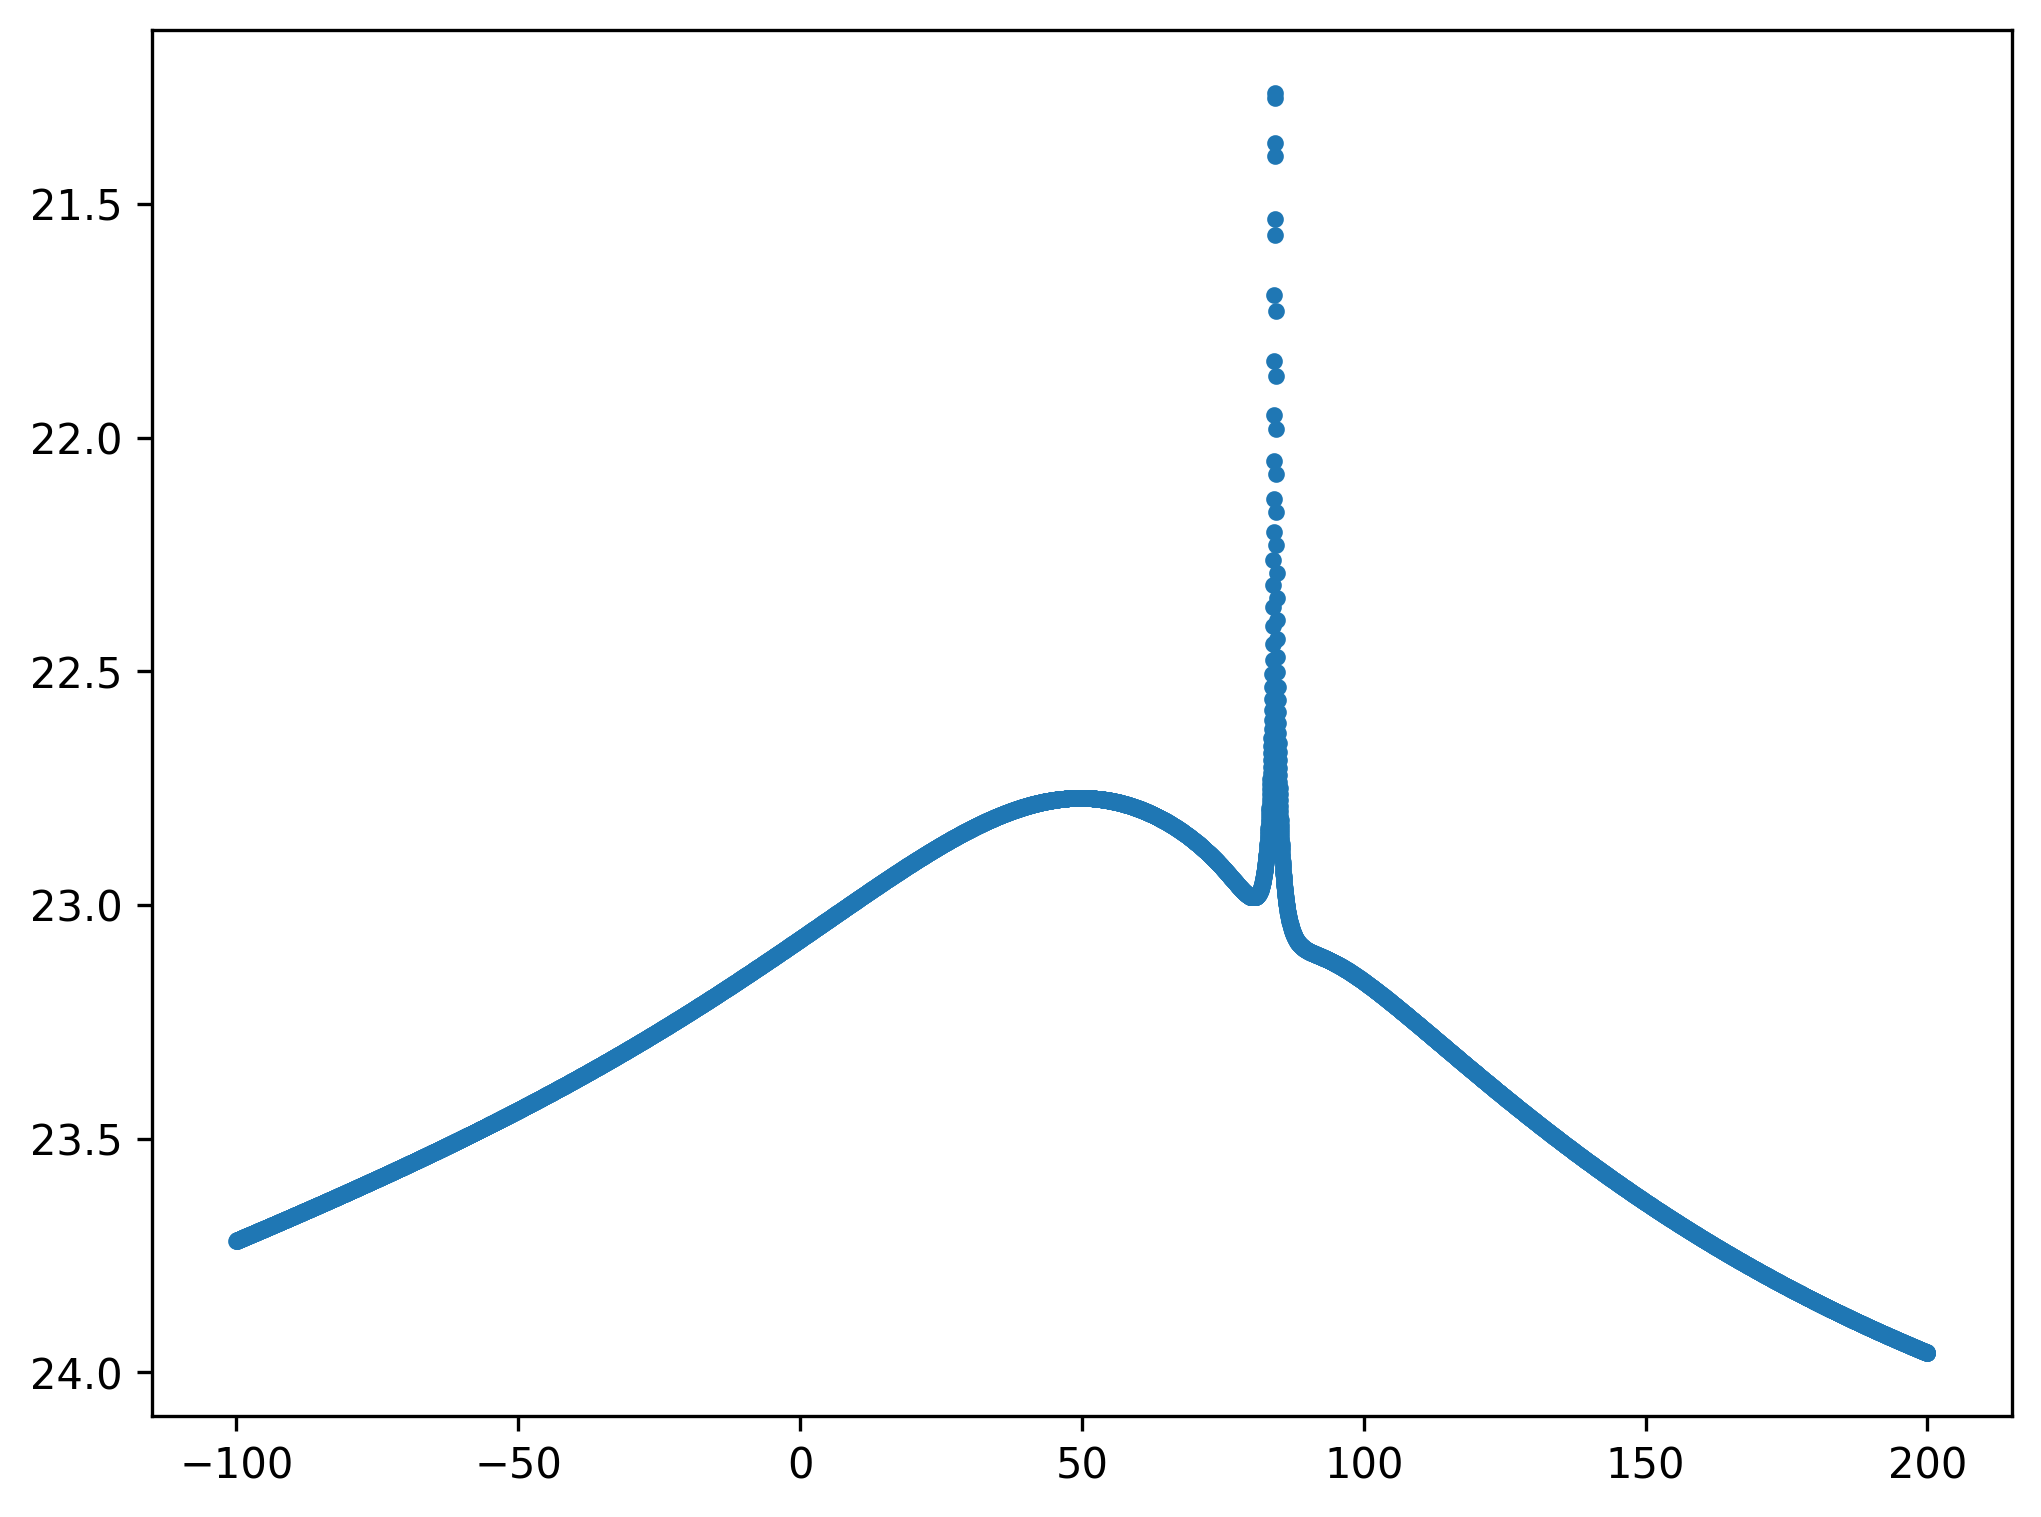

In [9]:
# my_own_creation = Event_roman_rubin(path_ephemerides, path_dataslice)
i=0
event_params= {
    "u": 24.853,
    "g": 22.55,
    "r": 21.529,
    "i": 21.133,
    "z": 20.945,
    "Y": 20.828,
    "W149": 20.8178,
    "radius": 0.513042,
    "D_S": 5156,
    "D_L": 2817,
    "mu_rel": 5.147491,
    "m_planet": ("9.462530108421484", "jupiterMass"),
    "m_star": ("18.65259824621826", "solMass"),
    "t0": 50.427461,
    "te": 351.034363,
    "u0": 0.147437,
    "rho": 0.000094,
    "piEE": -0.032015,
    "piEN": 0.005886,
    "s": 1.14786,
    "q": 0.000484,
    "alpha": 2.170221}

ZP = {'W149':27.615, 'u':27.03, 'g':28.38, 'r':28.16,
          'i':27.85, 'z':27.46, 'y':26.68}

my_own_creation = Event_rubin_dp0('Dp0 Example', 0.5, -1.25, 
                                  {'u':np.linspace(-100,200,10000)})

model, pyLIMA_parameters = sim_lightcurve(i, event_params, my_own_creation, 'USBL')
perfect_model = model_lightcurves_dp0(model, pyLIMA_parameters)

def dp0_pyLIMA(name, l, b, dict_bands_jd):
    my_own_creation = Event_rubin_dp0(name, l, b, dict_bands_jd)
    model, pyLIMA_parameters = sim_lightcurve(i, event_params, my_own_creation, 'USBL')
    perfect_model = model_lightcurves_dp0(model, pyLIMA_parameters)
    return perfect_model.event.lightcurve['mag']

plt.figure(figsize=(8,6),dpi=300)
for telo in perfect_model.event.telescopes:
    plt.plot(telo.lightcurve['time'],telo.lightcurve['mag'],marker='.',ls='')
plt.gca().invert_yaxis()


In [52]:
from photometric_parameters import PhotometricParameters

def set_photometric_parameters(exptime, nexp, readnoise=None):
    # readnoise = None will use the default (8.8 e/pixel). Readnoise should be in electrons/pixel.
    photParams = PhotometricParameters(exptime=exptime, nexp=nexp, readnoise=readnoise)
    return photParams

def filter_band(lightcurve, m5, fil):
    '''
    *Save the points of the lightcurve greater and smaller than
      1sigma fainter and brighter that the saturation and 5sigma_depth
    * check that the lightcurve have more than 10 points
    * check if the lightcurve have at least 1 point at 5 sigma from the 5sigma_depth
    '''
    # print(len(lightcurve))
    mag_sat = {'W149': 14.8, 'u': 14.7, 'g': 15.7, 'r': 15.8, 'i': 15.8, 'z': 15.3, 'y': 13.9}
    lightcurve['m5'] =  m5

    b1 = lightcurve['mag'].value - lightcurve['err_mag'].value > mag_sat[fil]
    b2 = lightcurve['mag'].value + lightcurve['err_mag'].value < lightcurve['m5']
    lc_fil1 = lightcurve[b1&b2]
    # display(lc_fil1)
    return lc_fil1
from signaltonoise import calc_mag_error_m5


def filter5points(pyLIMA_parameters, pyLIMA_telescopes):
    '''
    Check that at least one light curve
    have at least 5 pts in the t0+-tE
    '''
    t0 = pyLIMA_parameters['t0']
    tE = pyLIMA_parameters['tE']
    crit5pts = {}
    for telo in pyLIMA_telescopes:
        if not len(telo.lightcurve['mag']) == 0:
            x = telo.lightcurve['time'].value
            mask = (t0 - tE < x) & (x < t0 + tE)
            if len(x[mask]) >= 5: #cambiar a 10, 15
                crit5pts[telo.name] = True
            else:
                crit5pts[telo.name] = False
    return any(crit5pts.values())

def deviation_from_constant(pyLIMA_parameters, pyLIMA_telescopes):
    '''
     There at least four points in the range
     $[t_0-tE, t_0+t_E]$ with the magnification deviating from the
     constant flux by more than 3$\sigma$
    '''
    ZP = {'W149': 27.615, 'u': 27.03, 'g': 28.38, 'r': 28.16,
          'i': 27.85, 'z': 27.46, 'y': 26.68}
    t0 = pyLIMA_parameters['t0']
    tE = pyLIMA_parameters['tE']
    satis_crit = {}
    for telo in pyLIMA_telescopes:
        if not len(telo.lightcurve['mag']) == 0:
            mag_baseline = ZP[telo.name] - 2.5 * np.log10(pyLIMA_parameters['ftotal_' + f'{telo.name}'])
            x = telo.lightcurve['time'].value
            y = telo.lightcurve['mag'].value
            z = telo.lightcurve['err_mag'].value
            mask = (t0 - tE < x) & (x < t0 + tE)
            consec = []
            if len(x[mask]) >= 3:
                combined_lists = list(zip(x[mask], y[mask], z[mask]))
                sorted_lists = sorted(combined_lists, key=lambda item: item[0])
                sorted_x, sorted_y, sorted_z = zip(*sorted_lists)
                for j in range(len(sorted_y)):
                    if sorted_y[j] + 3 * sorted_z[j] < mag_baseline:
                        consec.append(j)
                result = has_consecutive_numbers(consec)
                if result:
                    satis_crit[telo.name] = True
                else:
                    satis_crit[telo.name] = False
            else:
                satis_crit[telo.name] = False
        else:
            satis_crit[telo.name] = False
    return any(satis_crit.values())

def has_consecutive_numbers(lst):
    """
    check if there at least 3 consecutive numbers in a list lst
    """
    sorted_lst = sorted(lst)
    for i in range(len(sorted_lst) - 2):
        if sorted_lst[i] + 1 == sorted_lst[i + 1] == sorted_lst[i + 2] - 1:
            return True
    return False
def sim_event(i, data, path_ephemerides, path_dataslice, model):
    '''
    i (int): index of the TRILEGAL data set
    data (dictionary): parameters including magnitude of the stars
    path_ephemerides (str): path to the ephemeris of Gaia
    path_dataslice(str): path to the dataslice obtained from OpSims
    model(str): model desired
    '''
    magstar = {'W149': data["W149"], 'u': data["u"], 'g': data["g"], 'r': data["r"],
               'i': data["i"], 'z': data["z"], 'y': data["Y"]}
    ZP = {'W149': 27.615, 'u': 27.03, 'g': 28.38, 'r': 28.16,
          'i': 27.85, 'z': 27.46, 'y': 26.68}

    dataSlice = np.load(path_dataslice, allow_pickle=True)
    LSST_BandPass = {}
    lsst_filterlist = 'ugrizy'
    for f in lsst_filterlist:
        LSST_BandPass[f] = Bandpass()
        LSST_BandPass[f].read_throughput(str(script_dir)+'/troughputs/' + f'total_{f}.dat')
        
    photParams = set_photometric_parameters(15, 2)

    my_own_creation = Event_roman_rubin(path_ephemerides, path_dataslice)
    new_creation = copy.deepcopy(my_own_creation)
    model, pyLIMA_parameters = sim_lightcurve(i, event_params, new_creation, model)
    my_own_model = model_lightcurves_RR(model, pyLIMA_parameters)

    np.random.seed(i)
    t0 = data['t0']
    tE = data['te']
    
    Roman_band = False
    Rubin_band = False
    for telo in my_own_model.event.telescopes:
        if telo.name == 'W149':
            # display(telo.lightcurve)
            telo.lightcurve['mag'] = (telo.lightcurve['mag'].value- 27.4 + ZP[telo.name])*u.mag
            m5 = np.ones(len(telo.lightcurve['mag'])) * 27.6
            telo.lightcurve = filter_band(telo.lightcurve, m5, telo.name)
            if not len(telo.lightcurve['mag']) == 0:
                Roman_band = True
        else:
            # display(telo.lightcurve)
            X = telo.lightcurve['time'].value
            ym = mag(ZP[telo.name], telo.lightcurve['flux'].value)
            z, y, x, M5 = [], [], [], []
            for k in range(len(ym)):
                m5 = dataSlice['fiveSigmaDepth'][np.where(dataSlice['filter'] == telo.name)][k]
                magerr = calc_mag_error_m5(ym[k], LSST_BandPass[telo.name], m5, photParams)[0]
                z.append(magerr)
                y.append(np.random.normal(ym[k], magerr))
                x.append(X[k])
                M5.append(m5)
            telo.lightcurve = filter_band(telo.lightcurve, m5, telo.name)

            if not len(telo.lightcurve['mag']) == 0:
                Rubin_band = True

    # This first if holds for an event with at least one Roman and Rubin band
    if Rubin_band and Roman_band:
        # This second if holds for a "detectable" event to fit
        if filter5points(pyLIMA_parameters, my_own_model.event.telescopes) and deviation_from_constant(pyLIMA_parameters, my_own_model.event.telescopes):
            print("A good event to fit")
            return my_own_model, pyLIMA_parameters, True
        else:
            print(
                "Not a good event to fit.\nFail 5 points in t0+-tE\nNot have 3 consecutives points that deviate from constant flux in t0+-tE")
            return my_own_model, pyLIMA_parameters, False
    else:
        print("Not a good event to fit since no Rubin band")
        return my_own_model, pyLIMA_parameters, False


my_own_model, pyLIMA_parameters, decision = sim_event(i, event_params, path_ephemerides, path_dataslice, 'USBL')


/home/anibal-pc/anaconda3/envs/pyLIMA_updated/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal-pc/anaconda3/envs/pyLIMA_updated/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 20736 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal-pc/anaconda3/envs/pyLIMA_updated/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 20736 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal-pc/anaconda3/envs/pyLIMA_updated/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal-pc/anaconda3/envs/pyLIMA_updated/lib/python3.11/

Parallax(Full) estimated for the telescope W149: SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
[np.str_('third_caustic'), [0, 0]]
Parallax(Full) estimated for the telescope W149: SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
A good event to fit


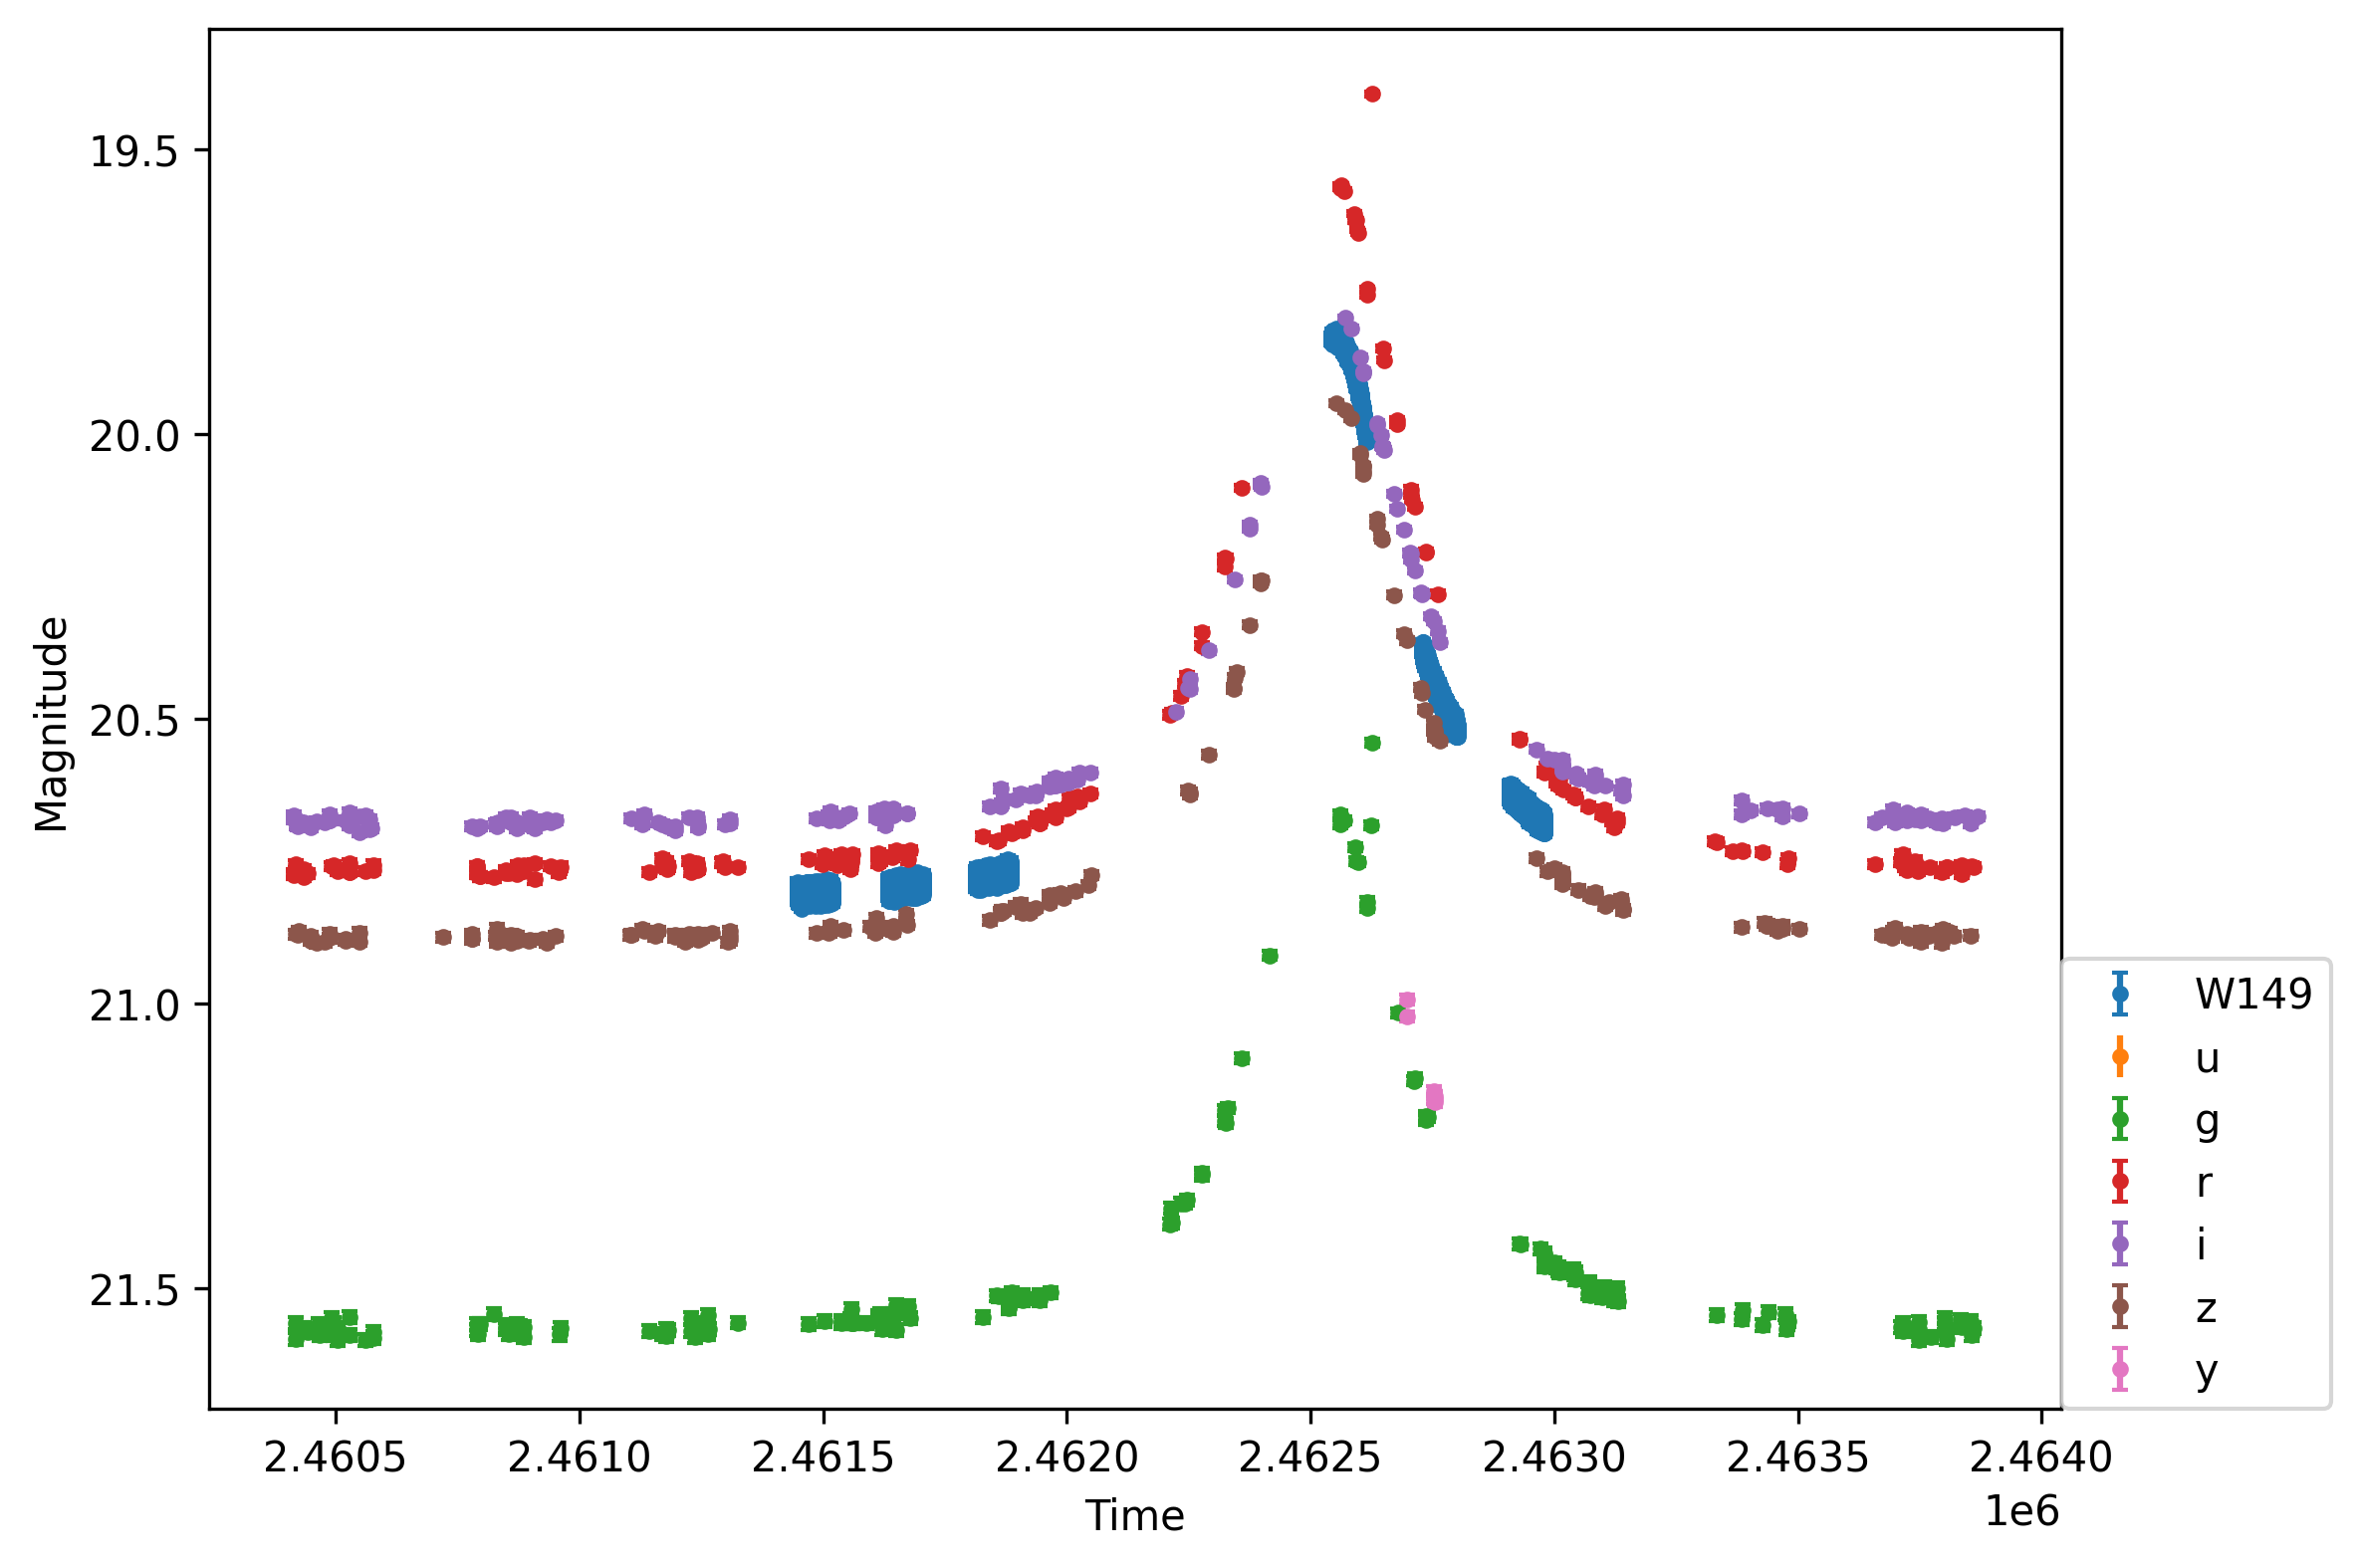

In [54]:
plt.figure(figsize=(8,6),dpi=300)
for telo in my_own_model.event.telescopes:
    plt.errorbar(telo.lightcurve['time'].value,telo.lightcurve['mag'].value,telo.lightcurve['err_mag'],marker='.',ls='',capsize=2,label=telo.name)

plt.xlabel('Time')
plt.ylabel('Magnitude')
plt.legend(loc=(1,0))
plt.gca().invert_yaxis()
plt.show()


In [2]:
import numpy as np
import pandas as pd
import os, sys
from pyLIMA import event
from scipy.signal import find_peaks
from tqdm.auto import tqdm
from pyLIMA import telescopes
from pyLIMA.models import USBL_model
from astropy.time import Time
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.table import QTable
from astropy.time import Time
from astropy.coordinates import SkyCoord


import copy
from pathlib import Path
# script_dir = Path(__file__).parent
# script_dir='/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/'
# sys.path.append(script_dir+'/roman_rubin/'+'/photutils/')

In [4]:
import sys
sys.path.append('/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/')
sys.path.append('/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/photutils/')

from dp0_utils import mag